# Análisis de los resultados

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
%matplotlib inline

RESULTS_DIR = Path('..') / 'results'

METRICS = [
    ('trimmed_mean_time_ms', 'Tiempo medio recortado (ms)'),
    ('trimmed_max_rss_mb', 'RSS máximo recortado (MB)'),
    ('trimmed_avg_cpu_percent', 'CPU promedio recortada (%)'),
]

In [2]:
rows = []

for path in sorted(RESULTS_DIR.glob('benchmark_*.json')):
    with path.open() as f:
        data = json.load(f)

    params = data.get('execution_params', {})
    summary = data.get('summary', {})

    rows.append({
        'mode': params.get('mode'),
        'workers': params.get('workers'),
        'trimmed_mean_time_ms': summary.get('trimmed_mean_time_ms'),
        'trimmed_max_rss_mb': summary.get('trimmed_max_rss_mb'),
        'trimmed_avg_cpu_percent': summary.get('trimmed_avg_cpu_percent'),
    })

df = pd.DataFrame(rows)

numeric_columns = ['workers'] + [metric for metric, _ in METRICS]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='raise')

print(f'Loaded {len(df)} benchmark reports from {len(rows)} JSON files')
print(f"Modes: {sorted(df['mode'].dropna().unique())}")
display(df.head(2))

Loaded 50 benchmark reports from 50 JSON files
Modes: ['concurrent', 'sequential']


,mode,workers,trimmed_mean_time_ms,trimmed_max_rss_mb,trimmed_avg_cpu_percent
0,concurrent,1,920.977872,479.756510,162.690495
1,concurrent,1,732.283583,488.042969,187.110005


In [3]:
sequential = df[df['mode'] == 'sequential'].copy()
concurrent = df[df['mode'] == 'concurrent'].copy()

baseline = sequential[[metric for metric, _ in METRICS]].mean()

config_agg = (
    concurrent
    .groupby(['workers'], as_index=False)
    .agg(
        trimmed_mean_time_ms=('trimmed_mean_time_ms', 'mean'),
        trimmed_max_rss_mb=('trimmed_max_rss_mb', 'mean'),
        trimmed_avg_cpu_percent=('trimmed_avg_cpu_percent', 'mean'),
    )
    .sort_values(['workers'])
    .reset_index(drop=True)
)

print(f'Aggregated into {len(config_agg)} worker configurations')
display(config_agg)

Aggregated into 6 worker configurations


,workers,trimmed_mean_time_ms,trimmed_max_rss_mb,trimmed_avg_cpu_percent
0,1,1112.157341,479.493815,199.828779
1,2,1548.179875,480.370443,232.165711
2,4,1187.346220,478.780070,244.055860
3,8,1172.658160,480.537313,247.817688
4,16,1179.148438,483.745239,244.551280
5,32,1174.652655,483.627035,238.048515


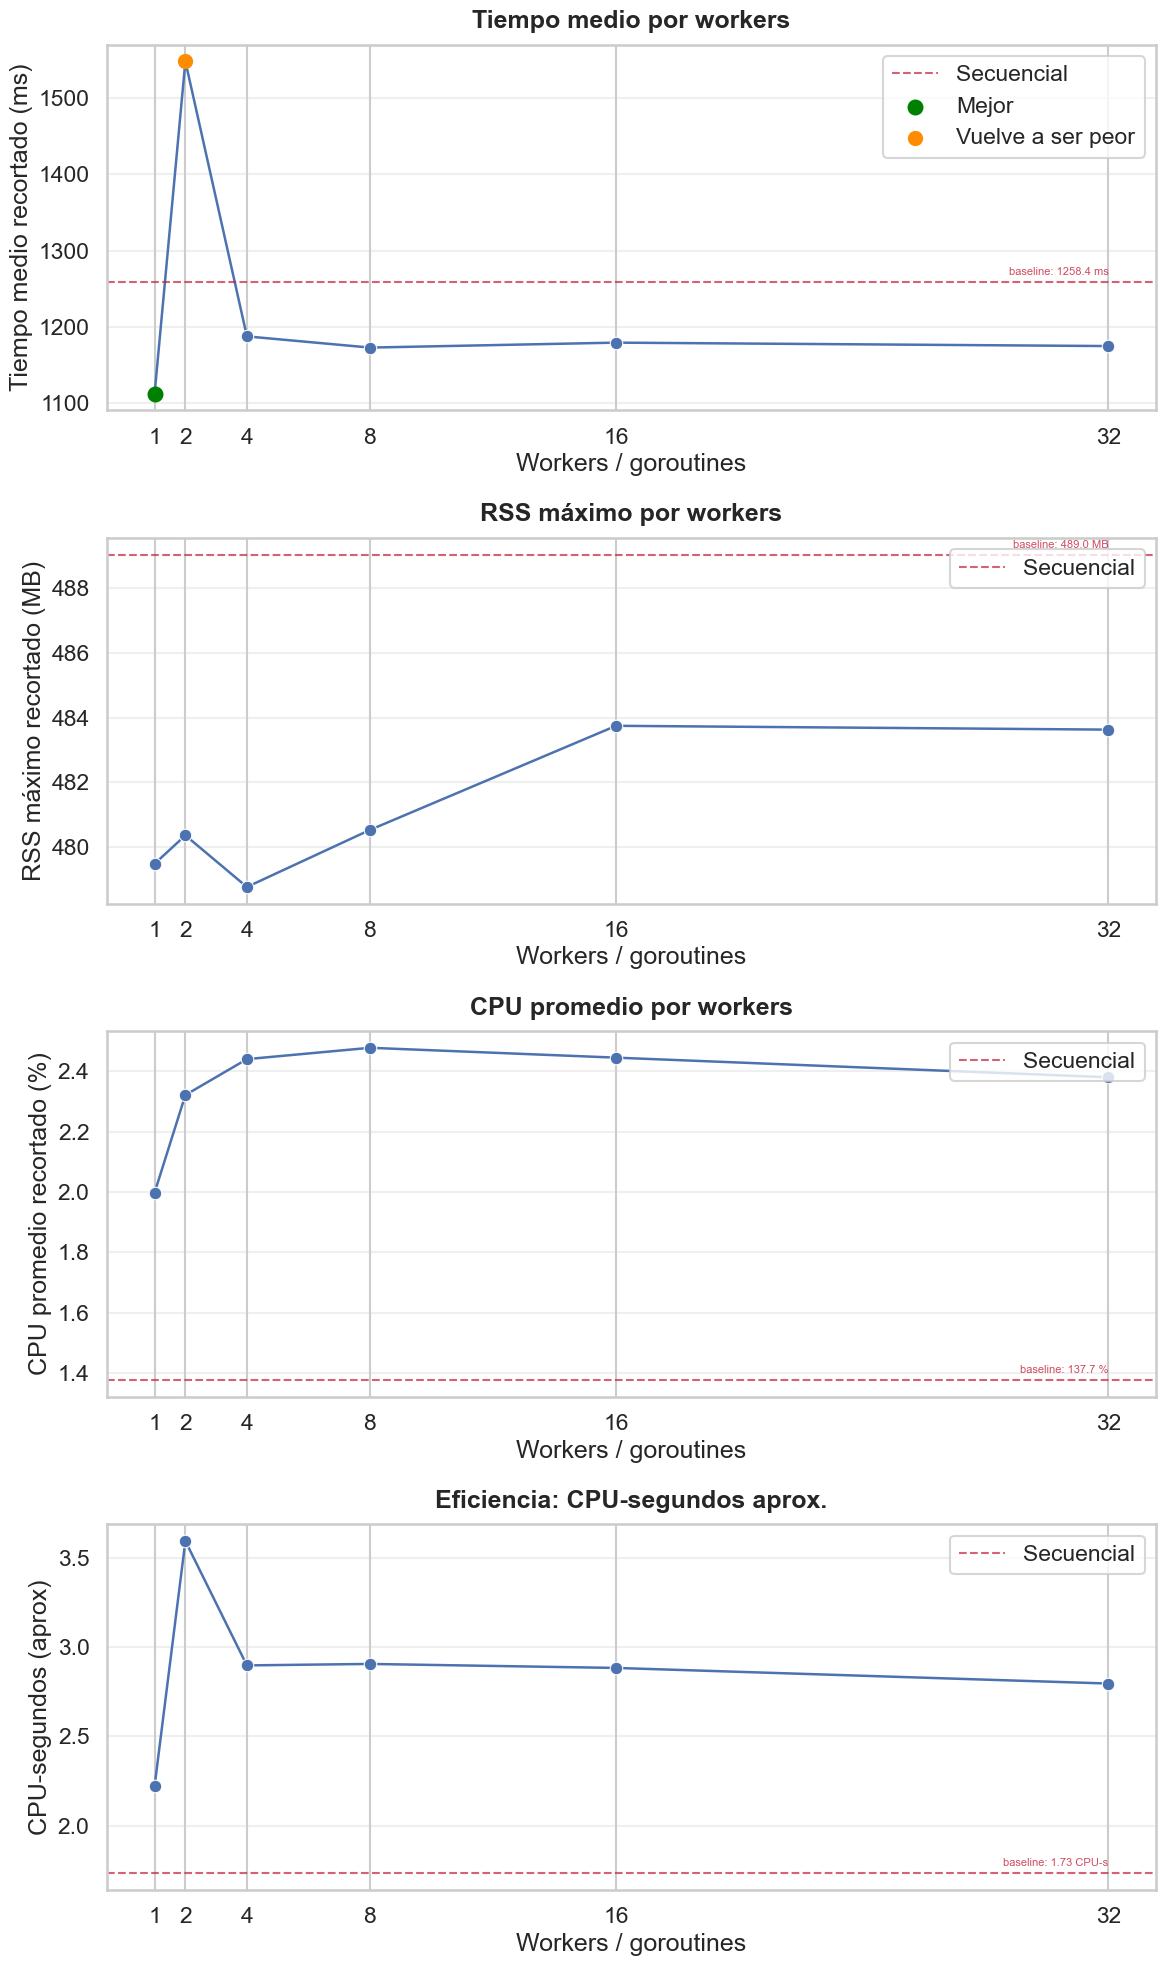

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 20))
worker_values = sorted(config_agg['workers'].dropna().unique().tolist())

# Helper to find special points: min, first <= baseline, first after min that becomes >= baseline
def special_points(frame: pd.DataFrame, metric_col: str, baseline_value: float):
    y = frame[metric_col].values
    workers = frame['workers'].values
    if len(y) == 0:
        return None, None, None

    # min point
    min_idx = int(np.nanargmin(y))
    min_worker = workers[min_idx]
    min_val = y[min_idx]

    # first point where value <= baseline (becomes faster/less)
    le_mask = y <= baseline_value
    first_le = workers[np.where(le_mask)[0][0]] if le_mask.any() else None
    first_le_val = frame.loc[frame['workers'] == first_le, metric_col].iloc[0] if first_le is not None else None

    # after min, first where value >= baseline (slows down again)
    after_min_mask = (workers > min_worker) & (y >= baseline_value)
    slow_again = workers[np.where(after_min_mask)[0][0]] if after_min_mask.any() else None
    slow_again_val = frame.loc[frame['workers'] == slow_again, metric_col].iloc[0] if slow_again is not None else None

    return (min_worker, min_val), (first_le, first_le_val), (slow_again, slow_again_val)

# 1) Time (ms)
ax = axes[0]
x = config_agg['workers']
y = config_agg['trimmed_mean_time_ms']
sns.lineplot(x=x, y=y, marker='o', linewidth=1.8, ax=ax)
baseline_time = float(baseline['trimmed_mean_time_ms'])
ax.axhline(baseline_time, color='#C41E3A', linestyle='--', linewidth=1.5, alpha=0.7, label='Secuencial')
ax.annotate(f'baseline: {baseline_time:.1f} ms', xy=(worker_values[-1], baseline_time), xytext=(0, 5), textcoords='offset pixels', fontsize=8, color='#C41E3A', ha='right', va='bottom', alpha=0.8)
min_pt, first_le_pt, slow_again_pt = special_points(config_agg, 'trimmed_mean_time_ms', baseline_time)
if min_pt is not None:
    ax.scatter(min_pt[0], min_pt[1], color='green', s=100, zorder=5, label='Mejor')
if first_le_pt is not None and first_le_pt[0] != min_pt[0]:
    ax.scatter(first_le_pt[0], first_le_pt[1], color='blue', s=90, zorder=5, label='Primer <= secuencial')
if slow_again_pt is not None:
    ax.scatter(slow_again_pt[0], slow_again_pt[1], color='#FF8C00', s=90, zorder=5, label='Vuelve a ser peor')
ax.set_title('Tiempo medio por workers', fontweight='bold', pad=12)
ax.set_xlabel('Workers / goroutines')
ax.set_ylabel('Tiempo medio recortado (ms)')
ax.set_xticks(worker_values)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', frameon=True)

# 2) RAM (MB)
ax = axes[1]
y = config_agg['trimmed_max_rss_mb']
sns.lineplot(x=config_agg['workers'], y=y, marker='o', linewidth=1.8, ax=ax)
baseline_rss = float(baseline['trimmed_max_rss_mb'])
ax.axhline(baseline_rss, color='#C41E3A', linestyle='--', linewidth=1.5, alpha=0.7, label='Secuencial')
ax.annotate(f'baseline: {baseline_rss:.1f} MB', xy=(worker_values[-1], baseline_rss), xytext=(0, 5), textcoords='offset pixels', fontsize=8, color='#C41E3A', ha='right', va='bottom', alpha=0.8)
ax.set_title('RSS máximo por workers', fontweight='bold', pad=12)
ax.set_xlabel('Workers / goroutines')
ax.set_ylabel('RSS máximo recortado (MB)')
ax.set_xticks(worker_values)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', frameon=True)

# 3) CPU (%)
ax = axes[2]
y = config_agg['trimmed_avg_cpu_percent'] / 100.0
sns.lineplot(x=config_agg['workers'], y=y, marker='o', linewidth=1.8, ax=ax)
baseline_cpu = float(baseline['trimmed_avg_cpu_percent']) / 100.0
ax.axhline(baseline_cpu, color='#C41E3A', linestyle='--', linewidth=1.5, alpha=0.7, label='Secuencial')
ax.annotate(f'baseline: {baseline_cpu * 100:.1f} %', xy=(worker_values[-1], baseline_cpu), xytext=(0, 5), textcoords='offset pixels', fontsize=8, color='#C41E3A', ha='right', va='bottom', alpha=0.8)
ax.set_title('CPU promedio por workers', fontweight='bold', pad=12)
ax.set_xlabel('Workers / goroutines')
ax.set_ylabel('CPU promedio recortado (%)')
ax.set_xticks(worker_values)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', frameon=True)

# 4) Efficiency: approx total CPU-seconds = (time_s) * (cpu_fraction)
ax = axes[3]
time_s = config_agg['trimmed_mean_time_ms'] / 1000.0
cpu_frac = config_agg['trimmed_avg_cpu_percent'] / 100.0
cpu_seconds = time_s * cpu_frac

sns.lineplot(x=config_agg['workers'], y=cpu_seconds, marker='o', linewidth=1.8, ax=ax)
baseline_cpu_seconds = (float(baseline['trimmed_mean_time_ms']) / 1000.0) * (float(baseline['trimmed_avg_cpu_percent']) / 100.0)
ax.axhline(baseline_cpu_seconds, color='#C41E3A', linestyle='--', linewidth=1.5, alpha=0.7, label='Secuencial')
ax.annotate(f'baseline: {baseline_cpu_seconds:.2f} CPU-s', xy=(worker_values[-1], baseline_cpu_seconds), xytext=(0, 5), textcoords='offset pixels', fontsize=8, color='#C41E3A', ha='right', va='bottom', alpha=0.8)
ax.set_title('Eficiencia: CPU-segundos aprox.', fontweight='bold', pad=12)
ax.set_xlabel('Workers / goroutines')
ax.set_ylabel('CPU-segundos (aprox)')
ax.set_xticks(worker_values)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()